In [4]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy


sys.path.append('..')
import plot_settings
plot_settings.apply()
colors = plot_settings.colors()

# Importing data

In [2]:
DT = 1
Q0 = 17921.57581 

In [8]:
def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        sep=';',
        comment="%"
    )
    return df

path = f'2_merged_data'

data = read_data(path)
data['eta'] = - data['eta']  # Negate eta to match model convention
display(data)

,u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
0,0.4,2.2,0.0,4.239833,10.952074,0.030566,-0.057493,4.324996,0.085164,0,-0.027881,-0.000470,0.999389
1,0.4,2.2,1.0,4.211952,10.952074,0.030096,-0.057493,4.323139,0.111187,0,-0.016738,-0.000471,0.998778
2,0.4,2.2,2.0,4.195213,10.952074,0.029624,-0.057493,4.321278,0.126065,0,-0.011734,-0.000471,0.998167
3,0.4,2.2,3.0,4.183479,10.952074,0.029153,-0.057493,4.319417,0.135938,0,-0.006706,-0.000471,0.997556
4,0.4,2.2,4.0,4.176773,10.952074,0.028682,-0.057493,4.317557,0.140783,0,-0.005763,-0.000471,0.996944
...,...,...,...,...,...,...,...,...,...,...,...,...,...
415552,15.9,1.4,2404.0,2.588773,6.969502,0.494206,-2.285347,3.283184,0.694411,247,-0.020117,-0.000300,0.064722
415553,15.9,1.4,2405.0,2.568657,6.969502,0.493907,-2.285347,3.281990,0.713334,247,-0.020923,-0.000300,0.064333
415554,15.9,1.4,2406.0,2.547734,6.969502,0.493607,-2.285347,3.280796,0.733063,247,-0.021729,-0.000300,0.063944
415555,15.9,1.4,2407.0,2.526005,6.969502,0.493307,-2.285347,3.279602,0.753597,247,-0.021729,-0.000300,0.063556


To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m

In [4]:
# Batch data
feature_cols = ['I', 'u', 'soc', 'Ue']
target_cols  = ['V', 'F', 'eta']

# Trajectories have unequal length — pad to longest and store a mask
traj_lengths = data['trajectory'].value_counts().sort_index().values
B     = len(traj_lengths)  # number of trajectories
T_max = traj_lengths.max()
Cx    = len(feature_cols)
Cy    = len(target_cols)

X_batched = torch.zeros(B, T_max, Cx)
Y_batched = torch.zeros(B, T_max, Cy)
mask      = torch.zeros(B, T_max, dtype=torch.bool)   # True where data exists

# Group by trajectory and fill the batches (rest = 0 (padding), mask = False)
for traj_id, grp in data.sort_values(['trajectory','t']).groupby('trajectory'):
    t_len = len(grp)
    X_batched[traj_id, :t_len, ...] = torch.tensor(grp[feature_cols].values, dtype=torch.float32)
    Y_batched[traj_id, :t_len, ...] = torch.tensor(grp[target_cols].values, dtype=torch.float32)
    mask[traj_id,      :t_len] = True

print(f"X_batched : {X_batched.shape}  (padded, use mask for loss)")
print(f"mask      : {mask.shape}")

X_batched : torch.Size([248, 7049, 4])  (padded, use mask for loss)
mask      : torch.Size([248, 7049])


In [5]:
# Split
split   = int(B * 0.8)
X_train = X_batched[:split]   # (B_train, T, Cx)
Y_train = Y_batched[:split]   # (B_train, T, Cy)
X_test  = X_batched[split:]   # (B_test,  T, Cx)
Y_test  = Y_batched[split:]   # (B_test,  T, Cy)
mask_train = mask[:split]
mask_test  = mask[split:]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


# DataLoaders
dataset_train = TensorDataset(X_train, Y_train, mask_train)
dataset_test  = TensorDataset(X_test,  Y_test, mask_test)

loader_train  = DataLoader(dataset_train, batch_size=X_train.shape[0]//4, shuffle=True)
loader_test   = DataLoader(dataset_test, batch_size=X_test.shape[0]//4, shuffle=False)

Train: torch.Size([198, 7049, 4])  |  Test: torch.Size([50, 7049, 4])


In [ ]:
def R0_func(u, I):
    ''' 
    Finds the R0 value for given u and I 
    Adjusts voltage curve 
    '''
    return u * (-0.0001887521) - 7.049519e-5 * I + 0.008446693

0.5316441632537718


In [ ]:
import torch.nn.functional as TF

def masked_mse(y_pred, y_target, mask):
    '''
    y_pred, y_true : (B, T_max)
    mask           : (B, T_max)      True where valid
    '''
    sq_err = (y_pred - y_target) ** 2
    return sq_err[mask].mean()  

class NeuralODE(nn.Module):
    def __init__(self, hidden_size=128):
        super().__init__()
        self.rc_dot_net = nn.Sequential(
            nn.Linear(4, hidden_size),  # [V_rc_t, I_t, u_t, soc_t]
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )


    def forward(self, x_b, eta0, mask=None, dt=2.0):
        I = x_b[:, :, 0]    # (B, T)
        u = x_b[:, :, 1]    # (B, T)
        U_eq = x_b[:, :, 3] # (B, T)

        ''' Rollout forward pass '''
        eta     = self.eta_rollout(x_b, eta0, mask)  # (B, T)
        eta_pred = eta
        V_pred   = U_eq - eta_pred

        ''' Rollout forward pass w. R0_function '''
        # V_rc0    = torch.zeros(x_b.shape[0])  # start with zero RC voltage
        # V_rc     = self.rc_rollout(x_b, V_rc0, mask)  # (B, T)
        # eta_pred = R0_func(u, I) * I + V_rc
        # V_pred   = U_eq - eta_pred

        return V_pred, eta_pred, eta#, F_pred

model = NeuralODE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
def training(epochs):
    history = {"loss": [], "V_loss": [], "F_loss": [], "time per ep": []}
    tot_time = 0.
    model.train()
    for ep in range(epochs):
        start_t      = time.perf_counter()
        ep_loss      = 0.0

        for x_b, y_b, mask_b in loader_train:

            loss = 0

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            ep_loss += loss.item()            

        ep_loss /= len(loader_train)
        history["loss"].append(ep_loss)
        end_t     = time.perf_counter()
        tot_time += end_t - start_t
        if ep == 0:
            print(f'ETA: {(end_t - start_t) * epochs / 60:.2f} min')
        if tot_time > 10 * 60:
            print("Early stopping.")
            break
        print(f"Epoch {ep+1} | loss {ep_loss:.2e} | teacher_ratio {teacher_ratio:.2f} | time {end_t-start_t:.2f}s")

    return history

In [321]:
history = training(epochs=10)

ETA: 0.87 min
Epoch 1 | loss 1.77e-01 | teacher_ratio 1.00 | time 5.23s
Epoch 2 | loss 2.01e-02 | teacher_ratio 0.90 | time 4.98s
Epoch 3 | loss 6.19e-03 | teacher_ratio 0.80 | time 5.21s
Epoch 4 | loss 2.54e-03 | teacher_ratio 0.70 | time 5.30s
Epoch 5 | loss 1.42e-03 | teacher_ratio 0.60 | time 5.18s
Epoch 6 | loss 1.09e-03 | teacher_ratio 0.50 | time 5.12s
Epoch 7 | loss 1.01e-03 | teacher_ratio 0.40 | time 4.83s
Epoch 8 | loss 1.12e-03 | teacher_ratio 0.30 | time 5.41s
Epoch 9 | loss 1.78e-03 | teacher_ratio 0.20 | time 5.30s
Epoch 10 | loss 3.88e-03 | teacher_ratio 0.10 | time 5.04s


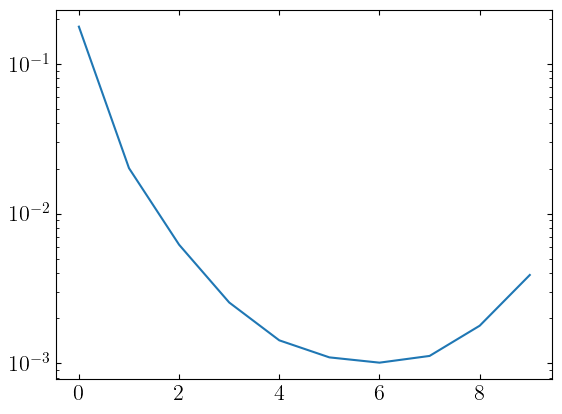

In [ ]:
fig = plt.figure(figsize=(6,4))
plt.semilogy(history["loss"], label="Total Loss")

[-8.789071e+00 -1.878907e+01 -2.878907e+01 ... -2.836879e+04 -2.837879e+04
 -2.838879e+04]


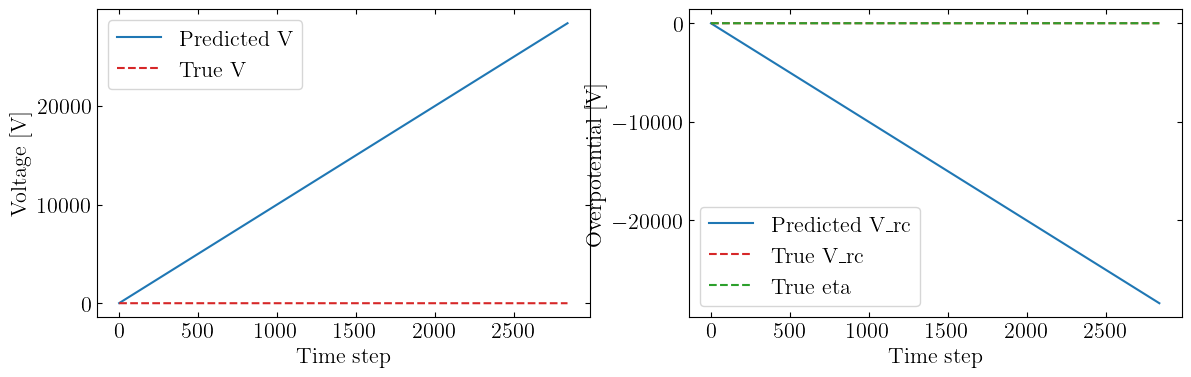

In [ ]:
def evaluate(model, x_test, y_test):
    model.eval()
    with torch.no_grad():
        pass
    return


V_rc_true = Y_test[:, :, 2] - R0_func(X_test[:, :, 1], X_test[:, :, 0]) * X_test[:, :, 0]

idx = 0
t_max = mask_test[idx].sum()

fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].plot(V_pred[idx, :t_max], color=colors[0], label="Predicted V")
axs[0].plot(Y_test[idx, :t_max, 0], linestyle='--', color=colors[1], label="True V")
axs[0].legend()
axs[0].set_ylabel("Voltage [V]")
axs[0].set_xlabel("Time step")
axs[1].plot(V_rc_pred[idx, :t_max], color=colors[0], label="Predicted V_rc")
axs[1].plot(V_rc_true[idx, :t_max], linestyle='--', color=colors[1], label="True V_rc")
axs[1].plot(Y_test[idx, :t_max, 2], linestyle='--', color=colors[2], label="True eta")
axs[1].legend()
axs[1].set_ylabel("Overpotential [V]")
axs[1].set_xlabel("Time step")
# axs[1].plot(eta_pred[idx, :t_max], color=colors[0], label="Predicted eta")

print(V_rc_pred[idx, :t_max])